In [1]:
import os
import ifcopenshell
from ifcopenshell.geom import create_shape
import pandas as pd
import numpy as np

In [2]:
import sys
#import bimquake
# sys.path.append("/content/drive/MyDrive/projects/BUILDCHAIN/IFC_to_wall_properties")
from building import Building
from utils import plot_by_plotly

In [3]:
from IPython.display import display

In [4]:
# ifc_file_path = "pilot_house_macchiavelli.ifc"
#ifc_file_path = "benchmark_house.ifc"
ifc_file_path = "toy_house.ifc"

In [5]:
ifc_file = ifcopenshell.open(ifc_file_path)

In [6]:
# Create B Building object - use the commented out command if
#B = IfcObjectSet(ifc_file, only_geometry=True)
B = Building(ifc_file, only_geometry=False, verbose=False)
B

<IfcObjectSet with 10 objects>

In [7]:
lat = 43.7874         # Latitude
longit = 11.2499        # Longitude
soil_cat = 'B'        # Soil category
nom_life = 50          # nomianl life
top_cat = 'T1'  # topographic catecory
imp_class = 'III'     #Importance class
q = 1.5   #Behaviour factor

In [8]:
S = B.generate_equivalent_frame_structural_model()

In [9]:
S.set_location(lat, longit)
S.set_seismic_design_parameters(soil_cat, nom_life, top_cat, imp_class, q)

Loading formatted geocoded file...


In [10]:
k_ult_TOT, Hult_TOT, vr_ult_TOT, L_organized = S.run_pushover_analysis(method="Ductility", algorithm="incr", mu=1.5)

c:\Users\Bence\bimquake-main\bimquake\ifc_processing\pushover_utils.py:437: RuntimeWarning: invalid value encountered in scalar divide
  delta0[i]=H0[i]/K0[i,k]


In [11]:
df = S.get_pushover_dataframe(k_ult_TOT, Hult_TOT, vr_ult_TOT)
df

,Direction,Safety Index,PGA_C,TR,δ,d* (t)
0,X,1.21,0.18,1273.0,1.2,1.07
1,Y,0.88,0.13,494.0,0.95,1.58


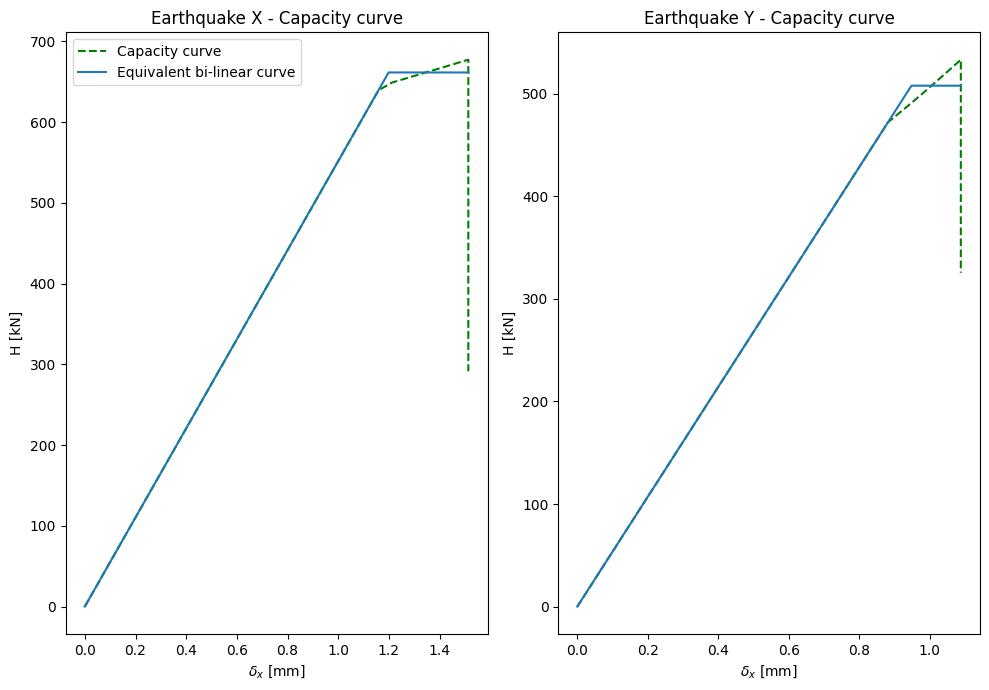

In [12]:
fig1 = S.get_capacity_plot(Hult_TOT, vr_ult_TOT)

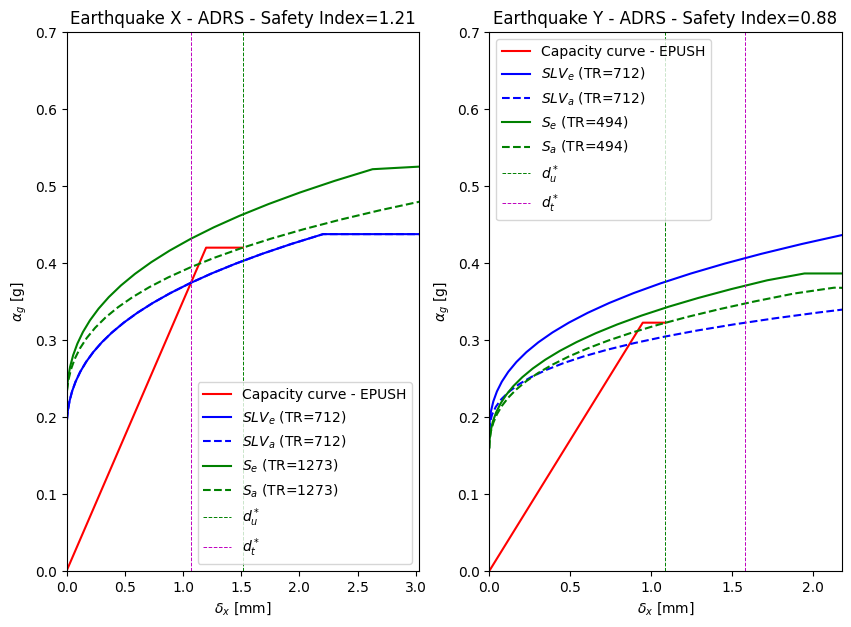

In [13]:
fig2 = S.get_ADRS_plot(k_ult_TOT, Hult_TOT, vr_ult_TOT)